# P24 — Combined-Axis Operating Point + Pareto Figure

**Purpose (Thesis_Final_Structure §2.3).** Show the compression axes *compose* into one
deployable model instead of only being reported in isolation, and draw the Chapter-7
Pareto figure. Stacks **no_gz** (drop gyro-z → 5 nodes) **+ AW-40** (60→40 timesteps)
**+ int8** (post-hoc dynamic quantization) on the locked P21 recipe.

**Non-destructive.** New files only: `p24/combined_axis.py`, `p24/pareto_figure.py`, and this
notebook. The combined model is trained by the *existing* `train_save.py` (it already accepts
`--nc` and `--aw` together) → new sibling dir `results/checkpoints/full_nc-no_gz_aw40`. Nothing
is overwritten.

**Cost.** One arm × 6 LODO folds at seed 42 (~<1 h GPU, resumable); int8 + the figure are
inference-only / no GPU. Seed 42 alone demonstrates *composition* — each constituent axis
already carries 5-seed error bars in `p24_seed_report_5.json`.


> **Final_PROJECT note (updated 2026-09-26).** All paths now come from
> `Final_PROJECT/project_paths.py` via the first code cell below — the only thing a new user may
> need to edit is the DAGHAR data path in that file (and `FINAL_PROJECT_ROOT` below, only if the
> folder isn't found automatically). **Saved cell outputs are from the original thesis run**, when
> this code lived at `/content/drive/MyDrive/Thesis/SO_Experiments/DAGHAR/P20_GraphRevival_DG/P24_SO_Compression`; they are kept as the record of that run.
> All training scripts are **resumable**: re-running this notebook in place skips any fold whose
> result files already exist, so it will not overwrite the thesis results.

## 1. Mount & paths
Identical layout to the other P24 notebooks. `P21_BASE` = the frozen ConvNet probs (seed 42)
used for the w=0.6 fusion.


In [ ]:
# ── Mount Drive & load Final_PROJECT paths (single source: Final_PROJECT/project_paths.py) ──
from google.colab import drive
drive.mount('/content/drive')
import os, sys, glob

# EDIT ONLY IF you uploaded Final_PROJECT somewhere else on your Drive
# (if this path doesn't exist, the folder is searched for automatically).
FINAL_PROJECT_ROOT = "/content/drive/MyDrive/Thesis/SO_Experiments/Final_PROJECT"

if not os.path.isfile(os.path.join(FINAL_PROJECT_ROOT, "project_paths.py")):
    hits = []
    for depth in range(0, 5):
        hits = glob.glob("/content/drive/MyDrive/" + "*/" * depth + "Final_PROJECT/project_paths.py")
        if hits: break
    assert hits, "Final_PROJECT not found on Drive — set FINAL_PROJECT_ROOT above"
    FINAL_PROJECT_ROOT = os.path.dirname(hits[0]); print("auto-detected Final_PROJECT at", FINAL_PROJECT_ROOT)
sys.path.insert(0, FINAL_PROJECT_ROOT)
import project_paths as PP            # the DAGHAR data path is set inside project_paths.py

PROJECT_PATH = PP.activate("p24")   # exports DATA_PATH, checks data, cd's into this component
DATA_PATH    = PP.DATA_PATH
P21_BASE     = PP.P21_BASE_S42     # frozen ConvNet probs (seed 42) for the w=0.6 fusion
os.environ["P21_BASE"] = P21_BASE  # used as "$P21_BASE" in the shell cells below
assert os.path.isdir(P21_BASE), "missing P21_BASE (frozen ConvNet probs for the fused numbers)"

## 2. Setup


In [2]:
import setup_colab
setup_colab.install_deps(); assert setup_colab.verify(), "fix DATA_PATH"

Installing PyTorch Geometric ...
Done.

Verifying imports ...
  OK torch 2.11.0+cu128  CUDA=True
     GPU Tesla T4
  OK torch_geometric 2.8.0

Checking data at: /content/drive/MyDrive/HAR-Datasets/DAGHAR/standardized_view
  OK KuHar              3 CSVs
  OK MotionSense        3 CSVs
  OK RealWorld-Thigh    3 CSVs
  OK RealWorld-Waist    3 CSVs
  OK UCI                3 CSVs
  OK WISDM              3 CSVs


## 3. Train the combined arm  (no_gz + AW-40, seed 42)
`train_save.py` handles `--nc` and `--aw` simultaneously; the arm auto-names
`full_nc-no_gz_aw40`. Resumable — re-run freely after a disconnect.


In [3]:
!python -m p24.train_save --data_path "$DATA_PATH" --variant full --nc no_gz --aw 40 --epochs 100 --log_every 20

[P24] train+save | arm=full_nc-no_gz_aw40 {'cnn_embed_dim': 64, 'gnn_hidden': 64, 'cnn_channels': [32, 64]} | nc=no_gz aw=40 | seed=42 | targets=['KuHar', 'MotionSense', 'RealWorld-Thigh', 'RealWorld-Waist', 'UCI', 'WISDM'] | out=/content/drive/MyDrive/Thesis/SO_Experiments/DAGHAR/P20_GraphRevival_DG/P24_SO_Compression/results/checkpoints/full_nc-no_gz_aw40
[LODO] target = KuHar
[LODO] sources = ['MotionSense', 'RealWorld-Thigh', 'RealWorld-Waist', 'UCI', 'WISDM']
[LODO] feature_mode = hybrid  normalize_mode = per_channel
[LODO] samples: train=35396  val=5412  test=144
[LODO] P24 NC: keeping channels [0, 1, 2, 3, 4] -> 5 nodes/graph
[LODO] P24 AW: 60 -> 40 timesteps/window (strided)
[LODO] P21 edge_mode=pearson  select=topk  topk=9  tau=0.3  alpha=0.5
    [pearson train] edges/window: mean 9.0  min 9  max 9  | most-kept pairs: (3, 4):100%, (1, 2):100%, (0, 1):100%, (0, 2):100%, (0, 3):100%
    [pearson val] edges/window: mean 9.0  min 9  max 9  | most-kept pairs: (0, 2):100%, (1, 4):10

## 4. Evaluate the stacked operating point  (+int8)
Inference-only: full-fp32 reference vs no_gz+AW-40 at fp32 and int8, fused w=0.6 vs `base_s42`.
Reports GNN/fused accuracy, deploy size, shrink factor, Δ vs full → `results/p24_combined_axis.json`.


In [4]:
!python -m p24.combined_axis --data_path "$DATA_PATH" --convnet_dir "$P21_BASE"

  [combined_axis] full  (reference, fp32) ...
[LODO] target = KuHar
[LODO] sources = ['MotionSense', 'RealWorld-Thigh', 'RealWorld-Waist', 'UCI', 'WISDM']
[LODO] feature_mode = hybrid  normalize_mode = per_channel
[LODO] samples: train=35396  val=5412  test=144
[LODO] P21 edge_mode=pearson  select=topk  topk=9  tau=0.3  alpha=0.5
    [pearson train] edges/window: mean 9.0  min 9  max 9  | most-kept pairs: (3, 4):100%, (3, 5):100%, (1, 2):100%, (1, 4):100%, (0, 2):100%
    [pearson val] edges/window: mean 9.0  min 9  max 9  | most-kept pairs: (0, 2):100%, (4, 5):100%, (3, 5):100%, (1, 4):100%, (2, 5):100%
    [pearson test] edges/window: mean 9.0  min 9  max 9  | most-kept pairs: (3, 5):100%, (1, 2):100%, (4, 5):100%, (0, 1):100%, (1, 4):100%
    feature_mode=hybrid, feat_dim=90, normalize_mode=per_channel
    building 35396 sensor graphs (6 nodes, 18 edges, 90 features each)...
    built 5000/35396 graphs
    built 10000/35396 graphs
    built 15000/35396 graphs
    built 20000/35396 g

## 5. Pareto figure  (no GPU)
Overlays every arm + the combined point on accuracy-vs-GNN-size and highlights the efficient
frontier → `results/p24_pareto.png` and `results/p24_pareto_points.csv`.


  saved /content/drive/MyDrive/Thesis/SO_Experiments/DAGHAR/P20_GraphRevival_DG/P24_SO_Compression/results/p24_pareto.png
  saved /content/drive/MyDrive/Thesis/SO_Experiments/DAGHAR/P20_GraphRevival_DG/P24_SO_Compression/results/p24_pareto_points.csv

  Pareto-efficient points: tiny, no_gz


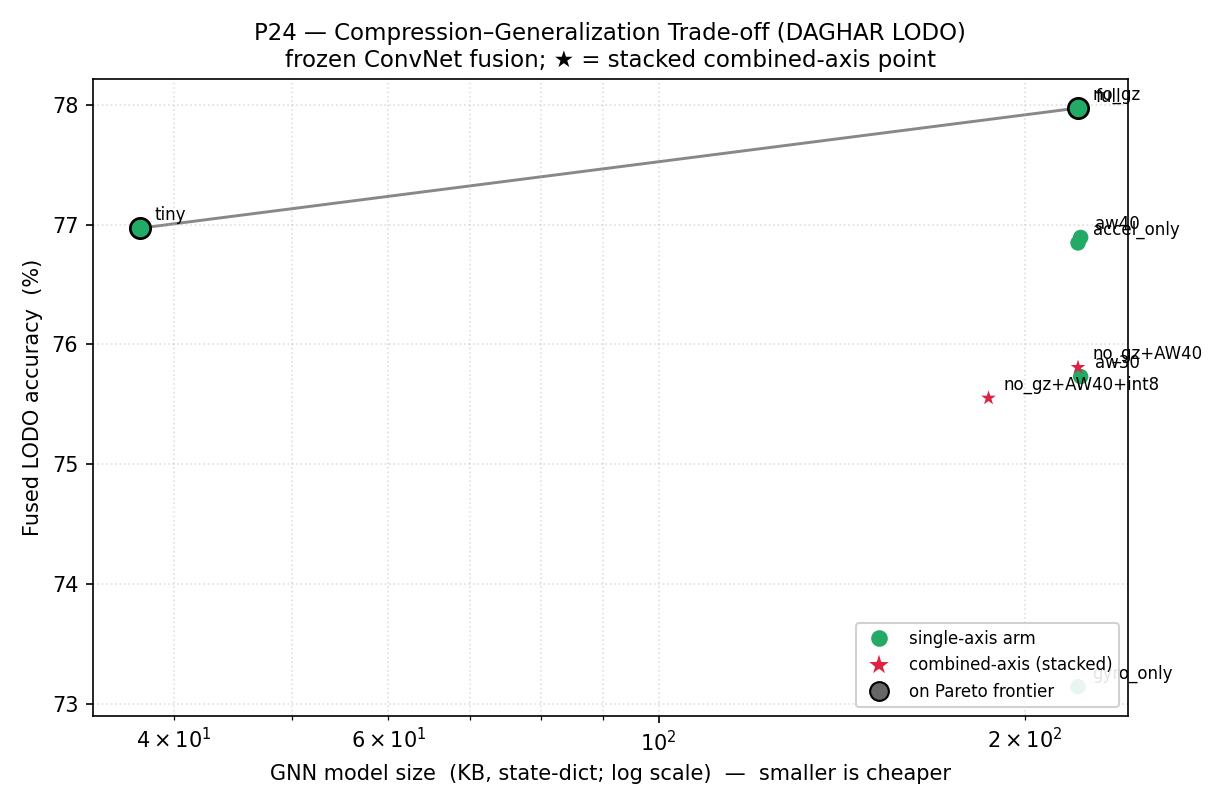

In [5]:
!python -m p24.pareto_figure
from IPython.display import Image
Image("results/p24_pareto.png")

## 6. Done
Share back: `results/p24_combined_axis.json`, `results/p24_pareto.png`, `results/p24_pareto_points.csv`.
These close §2.3 (axes compose) and give Chapter 7 its trade-off figure. Remaining §2 item is the
novelty-bar finalization (§2.5) — a decision, not a run.
